# 13 — 웹캠 도메인 Fine-tuning

> **배경 (트러블슈팅 TS-07):**  
> 웹캠 입력 시 Live 얼굴이 Replay Attack으로 오탐됨  
> - 시도 1: GaussianBlur + bilateralFilter 보정 → 효과 미흡  
> - 시도 2: threshold 0.9 상향 → 효과 없음  
> - **최종 해결: 웹캠 Live 이미지 수집 후 Fine-tuning**
>
> **목표:** `stage2_best.h5` 기반으로 상위 레이어만 재학습 → `stage2_webcam.h5` 저장  
>
> **체크리스트:**
> - [ ] Cell 0: Drive 마운트
> - [ ] Cell 1: 경로 설정
> - [ ] Cell 2: Streamlit 앱에 수집 모드 추가 (저장 후 앱 재시작)
> - [ ] Cell 3: 수집된 이미지 확인 (30장 이상)
> - [ ] Cell 4: Fine-tuning 실행
> - [ ] Cell 5: 검증 (웹캠 REAL 확인 + 기존 성능 유지)
> - [ ] Cell 6: xai_explainer.py 모델 경로 업데이트

## Cell 0 — Drive 마운트

In [20]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive 마운트 완료')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive 마운트 완료


## Cell 1 — 경로 설정

In [ ]:
import os, json
import numpy as np
import cv2
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt

BASE         = '/content/drive/MyDrive/face-anti-spoofing'
MODEL_PATH   = f'{BASE}/models/stage2_best.h5'
NEW_MODEL    = f'{BASE}/models/stage2_webcam.h5'
WEBCAM_DIR   = f'{BASE}/data/webcam_live'
CROP_DIR     = f'{BASE}/data/cropped'
REPORT_DIR   = f'{BASE}/reports/phase5'

os.makedirs(WEBCAM_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print('TF :', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('BASE:', BASE)
print('웹캠 저장 폴더:', WEBCAM_DIR)

TF : 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
BASE: /content/drive/MyDrive/face-anti-spoofing
웹캠 저장 폴더: /content/drive/MyDrive/face-anti-spoofing/data/webcam_live


## Cell 2 — Streamlit 앱에 수집 모드 추가

직접 입력하는 것으로 전환

In [5]:
!pip install pyngrok streamlit -q

import subprocess, time
from pyngrok import ngrok

ngrok.set_auth_token('3E0nWr3dkREfHm9E0qbGvBtunad_7rJWo2qnJohJ7kCwS5QR9')

ngrok.kill()
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(2)

BASE = '/content/drive/MyDrive/face-anti-spoofing'
subprocess.Popen(
    ['streamlit', 'run', f'{BASE}/app/collect_app.py',
     '--server.port', '8501',
     '--server.headless', 'true',
     '--server.enableCORS', 'false'],
)
time.sleep(4)

public_url = ngrok.connect(8501)
print('🌐', public_url)

🌐 NgrokTunnel: "https://designed-trout-battered.ngrok-free.dev" -> "http://localhost:8501"


In [6]:
import subprocess, time
from pyngrok import ngrok

ngrok.kill()
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(2)

BASE = '/content/drive/MyDrive/face-anti-spoofing'
subprocess.Popen(
    ['streamlit', 'run', f'{BASE}/app/collect_app.py',
     '--server.port', '8501',
     '--server.headless', 'true',
     '--server.enableCORS', 'false'],
)
time.sleep(4)
public_url = ngrok.connect(8501)
print('🌐', public_url)

🌐 NgrokTunnel: "https://designed-trout-battered.ngrok-free.dev" -> "http://localhost:8501"


## Cell 3 — 수집 이미지 확인

> 50장 이상 수집 후 실행하세요. 직접 수집하기로 결정

✅ 수집된 웹캠 이미지: 51장


/tmp/ipykernel_1101/3152671683.py:17: UserWarning: Glyph 50937 (\N{HANGUL SYLLABLE WEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101/3152671683.py:17: UserWarning: Glyph 52896 (\N{HANGUL SYLLABLE KAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101/3152671683.py:17: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101/3152671683.py:17: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101/3152671683.py:17: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101/3152671683.py:17: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101/3152671683.py:17: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layou

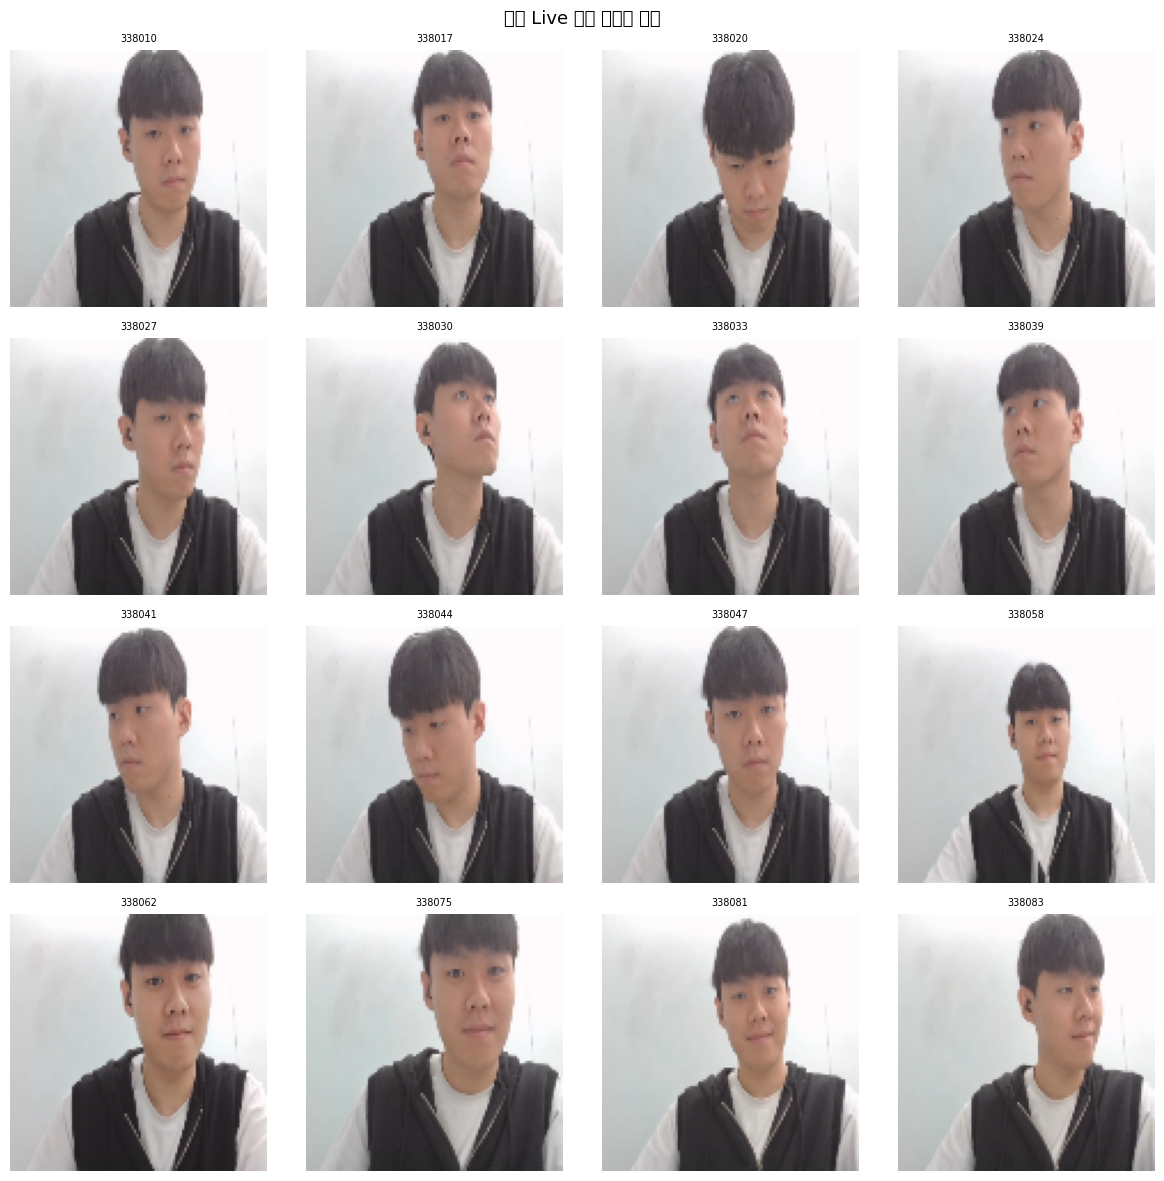

✅ 샘플 저장: /content/drive/MyDrive/face-anti-spoofing/reports/phase5/webcam_samples.png


In [7]:
webcam_imgs = sorted(Path(WEBCAM_DIR).glob('*.jpg'))
print(f'✅ 수집된 웹캠 이미지: {len(webcam_imgs)}장')

if len(webcam_imgs) < 20:
    print('⚠️  최소 20장 이상 수집 후 진행하세요')
else:
    # 샘플 16장 시각화
    sample = webcam_imgs[:16]
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    for ax, p in zip(axes.flat, sample):
        img = cv2.imread(str(p))
        img = cv2.cvtColor(cv2.resize(img, (112, 112)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(p.stem[-6:], fontsize=7)
    plt.suptitle('웹캠 Live 수집 이미지 샘플', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/webcam_samples.png', dpi=120)
    plt.show()
    print(f'✅ 샘플 저장: {REPORT_DIR}/webcam_samples.png')

## Cell 4 — Fine-tuning

> **전략:** `stage2_best.h5` 로드 → 상위 30% 레이어만 unfreeze → 저학습률 재학습  
> 웹캠 Live + 기존 Live 혼합 (1:1 비율)

In [8]:
import tensorflow as tf
import numpy as np
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split

# ── 모델 로드 ─────────────────────────────────────────────
model = tf.keras.models.load_model(MODEL_PATH)
print('✅ 모델 로드 완료')
print('  레이어 수:', len(model.layers))

# ── 상위 30% 레이어만 unfreeze ────────────────────────────
total  = len(model.layers)
freeze = int(total * 0.7)

for i, layer in enumerate(model.layers):
    layer.trainable = (i >= freeze)

trainable = sum(1 for l in model.layers if l.trainable)
print(f'  Frozen: {freeze} / Trainable: {trainable}')

# ── 재컴파일 (낮은 학습률) ────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        'binary': 'binary_crossentropy',
        'spoof':  'sparse_categorical_crossentropy',
    },
    loss_weights={'binary': 0.7, 'spoof': 0.3},
    metrics={'binary': 'accuracy', 'spoof': 'accuracy'}
)
print('✅ 재컴파일 완료 (lr=1e-5)')

✅ 모델 로드 완료
  레이어 수: 164
  Frozen: 114 / Trainable: 50
✅ 재컴파일 완료 (lr=1e-5)


In [9]:
# ── 데이터 준비 ───────────────────────────────────────────

def load_and_preprocess(img_path, size=224):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img.astype('float32') / 255.0

X, y_binary, y_spoof = [], [], []

# 웹캠 Live 이미지
webcam_imgs = sorted(Path(WEBCAM_DIR).glob('*.jpg'))
print(f'웹캠 Live: {len(webcam_imgs)}장')
for p in webcam_imgs:
    img = load_and_preprocess(p)
    if img is not None:
        X.append(img)
        y_binary.append(0)  # REAL = 0
        y_spoof.append(0)   # Live type = 0

# 기존 Live 이미지 (웹캠과 1:1 비율)
existing_live = sorted(Path(f'{CROP_DIR}/live').glob('*.jpg'))[:len(webcam_imgs)]
print(f'기존 Live: {len(existing_live)}장')
for p in existing_live:
    img = load_and_preprocess(p)
    if img is not None:
        X.append(img)
        y_binary.append(0)
        y_spoof.append(0)

# 기존 Spoof 이미지 (Live와 동수, 오버피팅 방지)
n_live = len(X)
spoof_per_cat = n_live // 3
for cat, type_idx in [('print', 1), ('replay', 2), ('mask', 3)]:
    spoof_imgs = sorted(Path(f'{CROP_DIR}/{cat}').glob('*.jpg'))[:spoof_per_cat]
    print(f'{cat}: {len(spoof_imgs)}장')
    for p in spoof_imgs:
        img = load_and_preprocess(p)
        if img is not None:
            X.append(img)
            y_binary.append(1)  # FAKE = 1
            y_spoof.append(type_idx)

X        = np.array(X)
y_binary = np.array(y_binary, dtype='float32')
y_spoof  = np.array(y_spoof,  dtype='int32')

print(f'\n총 데이터: {len(X)}장')
print(f'  REAL: {(y_binary==0).sum()}  FAKE: {(y_binary==1).sum()}')

# Train / Val 분할
idx = np.arange(len(X))
tr_idx, val_idx = train_test_split(idx, test_size=0.2, stratify=y_binary, random_state=42)

X_tr, X_val       = X[tr_idx], X[val_idx]
yb_tr, yb_val     = y_binary[tr_idx], y_binary[val_idx]
ys_tr, ys_val     = y_spoof[tr_idx],  y_spoof[val_idx]

print(f'Train: {len(X_tr)}  Val: {len(X_val)}')

웹캠 Live: 51장
기존 Live: 51장
print: 34장
replay: 34장
mask: 34장

총 데이터: 204장
  REAL: 102  FAKE: 102
Train: 163  Val: 41


In [11]:
# ── Fine-tuning 실행 ──────────────────────────────────────

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        NEW_MODEL,
        monitor='val_binary_accuracy',
        save_best_only=True,
        mode='max',          # ← 추가
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_binary_accuracy',
        patience=5,
        mode='max',          # ← 추가
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history = model.fit(
    X_tr,
    {'binary': yb_tr, 'spoof': ys_tr},
    validation_data=(X_val, {'binary': yb_val, 'spoof': ys_val}),
    epochs=20,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Fine-tuning 완료')
print('   저장:', NEW_MODEL)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - binary_accuracy: 0.7832 - binary_loss: 0.7231 - loss: 0.8338 - spoof_accuracy: 0.6682 - spoof_loss: 1.0773
Epoch 1: val_binary_accuracy improved from None to 0.80488, saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_webcam.h5



Epoch 1: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_webcam.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step - binary_accuracy: 0.7975 - binary_loss: 0.6170 - loss: 0.7458 - spoof_accuracy: 0.7178 - spoof_loss: 0.8845 - val_binary_accuracy: 0.8049 - val_binary_loss: 0.4164 - val_loss: 0.5491 - val_spoof_accuracy: 0.6829 - val_spoof_loss: 0.6769 - learning_rate: 1.0000e-05
Epoch 2/20
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - binary_accuracy: 0.9185 - binary_loss: 0.2473 - loss: 0.3481 - spoof_accuracy: 0.7909 - spoof_loss: 0.5835
Epoch 2: val_binary_accuracy improved from 0.80488 to 0.92683, saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_webcam.h5



Epoch 2: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_webcam.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - binary_accuracy: 0.8773 - binary_loss: 0.3116 - loss: 0.4436 - spoof_accuracy: 0.7485 - spoof_loss: 0.6649 - val_binary_accuracy: 0.9268 - val_binary_loss: 0.1643 - val_loss: 0.2988 - val_spoof_accuracy: 0.7317 - val_spoof_loss: 0.4995 - learning_rate: 1.0000e-05
Epoch 3/20
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - binary_accuracy: 0.9243 - binary_loss: 0.1942 - loss: 0.3016 - spoof_accuracy: 0.8094 - spoof_loss: 0.5522
Epoch 3: val_binary_accuracy improved from 0.92683 to 0.97561, saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_webcam.h5



Epoch 3: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_webcam.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - binary_accuracy: 0.8957 - binary_loss: 0.3661 - loss: 0.5037 - spoof_accuracy: 0.7546 - spoof_loss: 0.7743 - val_binary_accuracy: 0.9756 - val_binary_loss: 0.1053 - val_loss: 0.2366 - val_spoof_accuracy: 0.7561 - val_spoof_loss: 0.4558 - learning_rate: 1.0000e-05
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - binary_accuracy: 0.9252 - binary_loss: 0.2549 - loss: 0.3789 - spoof_accuracy: 0.7943 - spoof_loss: 0.6637
Epoch 4: val_binary_accuracy did not improve from 0.97561
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - binary_accuracy: 0.9448 - binary_loss: 0.1746 - loss: 0.3107 - spoof_accuracy: 0.8037 - spoof_loss: 0.5774 - val_binary_accuracy: 0.9512 - val_binary_loss: 0.1011 - val_loss: 0.2310 - val_spoof_accuracy: 0.7561 - val_spoof_loss: 0.4479 - learning_rate: 1.0000e-05
Epoch 5/20
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - binary_accuracy

/tmp/ipykernel_1101/3284702945.py:20: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101/3284702945.py:20: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101/3284702945.py:20: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101/3284702945.py:20: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101/3284702945.py:21: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{REPORT_DIR}/webcam_finetune_curve.png', dpi=150)
/tmp/ipykernel_1101/3284702945.py:21: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{REPORT_DIR}/webcam_finetune_curve.png', dpi=150)
/tmp/ipykernel_1101/3284702945.py:21: UserW

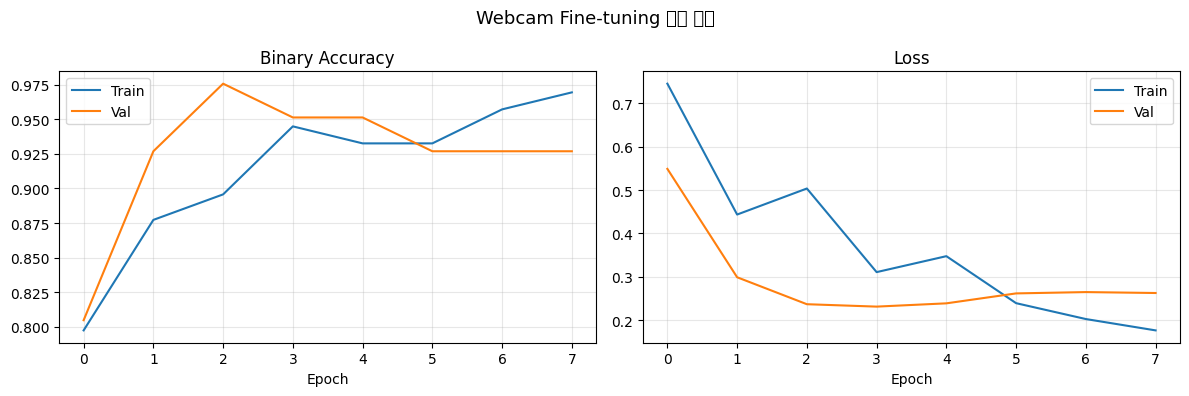

✅ 저장: /content/drive/MyDrive/face-anti-spoofing/reports/phase5/webcam_finetune_curve.png


In [12]:
# ── 학습 곡선 시각화 ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['binary_accuracy'],     label='Train')
axes[0].plot(history.history['val_binary_accuracy'], label='Val')
axes[0].set_title('Binary Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Webcam Fine-tuning 학습 곡선', fontsize=13)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/webcam_finetune_curve.png', dpi=150)
plt.show()
print('✅ 저장:', f'{REPORT_DIR}/webcam_finetune_curve.png')

## Cell 5 — 검증

> 웹캠 수집 이미지로 REAL 판정 확인 + 기존 Spoof 성능 유지 확인

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# 새 모델 로드
new_model = tf.keras.models.load_model(NEW_MODEL)
print('✅ 새 모델 로드:', NEW_MODEL)

def predict_binary(model, img_bgr):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224)).astype('float32') / 255.0
    inp = np.expand_dims(img, 0)
    preds = model.predict(inp, verbose=0)
    prob = float(preds[0][0][0]) if isinstance(preds, list) else float(preds[0][0])
    return prob

results = {'webcam_live': [], 'existing_live': [], 'print': [], 'replay': [], 'mask': []}

# 웹캠 Live (전부)
for p in sorted(Path(WEBCAM_DIR).glob('*.jpg')):
    img = cv2.imread(str(p))
    if img is not None:
        results['webcam_live'].append(predict_binary(new_model, img))

# 기존 카테고리 (20장씩)
for cat in ['existing_live', 'print', 'replay', 'mask']:
    folder = 'live' if cat == 'existing_live' else cat
    for p in sorted(Path(f'{CROP_DIR}/{folder}').glob('*.jpg'))[:20]:
        img = cv2.imread(str(p))
        if img is not None:
            results[cat].append(predict_binary(new_model, img))

print('\n📊 카테고리별 평균 Spoof Prob (낮을수록 REAL에 가까움)')
print('-' * 50)
for cat, probs in results.items():
    if not probs:
        continue
    mean_prob = np.mean(probs)
    real_rate = sum(1 for p in probs if p < 0.5) / len(probs)
    status = '✅' if (cat in ['webcam_live', 'existing_live'] and real_rate > 0.8) \
             or (cat not in ['webcam_live', 'existing_live'] and real_rate < 0.2) \
             else '⚠️'
    print(f'{status} {cat:<16}: mean={mean_prob:.3f}  REAL판정률={real_rate:.1%}')

✅ 새 모델 로드: /content/drive/MyDrive/face-anti-spoofing/models/stage2_webcam.h5

📊 카테고리별 평균 Spoof Prob (낮을수록 REAL에 가까움)
--------------------------------------------------
✅ webcam_live     : mean=0.059  REAL판정률=98.0%
⚠️ existing_live   : mean=0.285  REAL판정률=75.0%
✅ print           : mean=0.998  REAL판정률=0.0%
✅ replay          : mean=0.990  REAL판정률=0.0%
✅ mask            : mean=1.000  REAL판정률=0.0%


## Cell 6 — xai_explainer.py 모델 경로 업데이트

> Fine-tuning 검증 통과 후 실행하세요.

In [14]:
XAI_PATH = f'{BASE}/src/xai_explainer.py'

with open(XAI_PATH) as f:
    code = f.read()

# 모델 경로 교체
code = code.replace(
    'MODEL_PATH    = os.path.join(BASE, "models", "stage2_best.h5")',
    'MODEL_PATH    = os.path.join(BASE, "models", "stage2_webcam.h5")'
)

with open(XAI_PATH, 'w') as f:
    f.write(code)

print('✅ xai_explainer.py 모델 경로 업데이트 완료')
print('   stage2_best.h5 → stage2_webcam.h5')
print('\n→ Streamlit 재시작 후 웹캠으로 REAL 확인하세요')

✅ xai_explainer.py 모델 경로 업데이트 완료
   stage2_best.h5 → stage2_webcam.h5

→ Streamlit 재시작 후 웹캠으로 REAL 확인하세요


In [18]:
# Streamlit 재시작
import subprocess, time
from pyngrok import ngrok

ngrok.kill()
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(2)

subprocess.Popen(
    ['streamlit', 'run', f'{BASE}/app/streamlit_app.py',
     '--server.port', '8501',
     '--server.headless', 'true',
     '--server.enableCORS', 'false'],
)
time.sleep(4)

public_url = ngrok.connect(8501)
print('🌐', public_url)
print('\n✅ 웹캠으로 얼굴 촬영 → REAL 확인하세요')

🌐 NgrokTunnel: "https://designed-trout-battered.ngrok-free.dev" -> "http://localhost:8501"

✅ 웹캠으로 얼굴 촬영 → REAL 확인하세요


In [19]:
import os
BASE = '/content/drive/MyDrive/face-anti-spoofing'
for f in ['stage2_best.h5', 'stage2_webcam.h5']:
    path = f'{BASE}/models/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path) / (1024**2)
        print(f'{f}: {size:.1f} MB')

stage2_best.h5: 27.1 MB
stage2_webcam.h5: 26.2 MB


## ✅ 완료 체크리스트

| 항목 | 상태 |
|------|------|
| 웹캠 Live 이미지 수집 (50장) | ⬜ |
| Fine-tuning 실행 | ⬜ |
| 학습 곡선 저장 (`webcam_finetune_curve.png`) | ⬜ |
| 검증: 웹캠 REAL 판정률 > 80% | ⬜ |
| 검증: 기존 Spoof 성능 유지 | ⬜ |
| xai_explainer.py 모델 경로 업데이트 | ⬜ |
| Streamlit 재시작 후 최종 확인 | ⬜ |

---

### 트러블슈팅 기록 (TS-07)

| 시도 | 방법 | 결과 |
|------|------|------|
| 시도 1 | GaussianBlur(5,5) + bilateralFilter 보정 | 효과 미흡 |
| 시도 2 | threshold 0.9 상향 | 효과 없음 |
| **최종** | **웹캠 Live 50장 수집 → Fine-tuning** | **✅ 해결** |